## Matthieu Beylard-Ozeroff - Semester Project at the Mathis Group for Computational Neuroscience and AI

---

## 0. Context

### Scientific Background: Hierarchical Motor Control

This notebook reproduces the computational findings of the paper **"Parallel feedback processing for voluntary control: knowledge of spinal feedback in motor cortex"** by Guang et al. (2024).The central question of the study is how the nervous system coordinates fast, low-level spinal reflexes with slower, high-level cortical responses to stabilize the limb.

* **Biological Fact (Gain Scaling):** Spinal reflexes are not constant; they increase in strength (gain) when background muscle activity increases (e.g., holding a heavy load).

* **The Problem:** If spinal reflexes get stronger, but the cortex keeps pushing just as hard, the system would over-correct and become unstable.

* **The Hypothesis (Reciprocal Reduction):** To maintain stability and efficiency, the Primary Motor Cortex (M1) must "know" about the state of the spinal cord. When spinal gains are high (High Load), the cortex should reduce its output.

### The Computational Model

To test this, we simulate a biologically plausible Neural-Limb Model  consisting of:

1. **Musculoskeletal Plant:** A 2-DOF arm (Shoulder/Elbow) driven by 6 Hill-type muscles.

2. **Spinal Cord:** A feedback loop with variable gains (Gs) that scale with background load.

3. **Cortical Controller:** A Recurrent Neural Network (RNN) representing the Sensory and Motor cortices, optimized to control the arm via descending commands.

### Reproduction Goals

We train this system using differentiable physics to perform a postural perturbation task. By optimizing for kinematic accuracy and metabolic energy cost, we aim to demonstrate that reciprocal reduction is an emergent property of optimal motor control:

* **Task:** Maintain hand position at  against random mechanical perturbations under Low and High background loads.

* **Prediction:** After training, the RNN should learn to lower its activity in High Load conditions, effectively "offloading" the stabilization task to the strengthened spinal reflexes.

## 1. Imports

This cell imports the necessary libraries for the simulation: standard utilities (`os`, `random`, `deque`), scientific computing packages (`numpy`, `torch`), visualization tools (`matplotlib`), and the custom biomechanical environment (`MyoElbowPose2D6MFixed`).

In [ ]:
# Standard library
import os
import random
from collections import deque

# Third-party scientific
import numpy as np
import torch
import torch.nn as nn

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib import colormaps
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D

# Custom environment
from environment import MyoElbowPose2D6MFixed

## 2. Configuration & Constants

This cell defines the core simulation parameters, including time steps, biological delays (cortical, spinal), neural network dimensions, feedback gains, and biomechanical properties (arm lengths, moment arms). It also sets up the training hyperparameters (cost weights, load conditions) and defines the directional perturbation tasks for the experiment.

In [86]:
# --- Simulation Time Parameters ---
dt = 0.01
tau_n = 0.02
tau_m = 0.05

Tb, Tsb, Tp, Tsp, T = 0.20, 1.00, 1.50, 2.50, 3.00
Tb_step = int(Tb / dt)
Tsb_step = int(Tsb / dt)
Tp_step = int(Tp / dt)
Tsp_step = int(Tsp / dt)
T_step = int(T / dt)

activation_delay_steps = int(0.03 / dt)
feedback_delay_steps = int(0.04 / dt)
reflex_delay = int(0.02 / dt)

# --- Neural Network & Gains ---
n_s, n_m1, n_muscles, n_inputs = 200, 200, 6, 10
G_p, G_d, G_f = 1.0, 1.0, 1.0
G_aff = torch.tensor([1.0, 0.1, 0.01, 0.0001])
G_s_low, G_s_high = 0.8, 1.9

# --- Biomechanics & Physics ---
l1, l2 = 0.12, 0.10  # Arm segment lengths

# Moment arm matrix (Muscle geometry)
M_m = torch.tensor([
    [ 0.10,  0.00],       # Muscle 0: Mono Shoulder Flexor
    [-0.10,  0.00],       # Muscle 1: Mono Shoulder Extensor
    [ 0.00,  0.10],       # Muscle 2: Mono Elbow Flexor
    [ 0.00, -0.10],       # Muscle 3: Mono Elbow Extensor
    [ 0.08,  0.08],       # Muscle 4: Bi-articular Flexor
    [-0.08, -0.08]        # Muscle 5: Bi-articular Extensor
], dtype=torch.float32)

# --- Training & Costs ---
alpha, beta, gamma = 0.0001, 0.001, 0.5  # Penalty coefficients
background_load_low, background_load_high, perturbation_load = 0.1, 0.55, 0.25

# --- Task Definitions ---
perturbation_directions = {
    "Right": np.array([1.0, 0.0]), "Left": np.array([-1.0, 0.0]),
    "Up": np.array([0.0, 1.0]), "Down": np.array([0.0, -1.0]),
    "Up-Right": np.array([0.707, 0.707]), "Up-Left": np.array([-0.707, 0.707]),
    "Down-Left": np.array([-0.707, -0.707]), "Down-Right": np.array([0.707, -0.707])
}

## 3. Biomechanics & Physics Helpers

This cell implements the physiological and physical models of the system. It defines Hill-type muscle dynamics (Force-Length and Force-Velocity relationships) , computes arm kinematics (Jacobians, forward kinematics), and includes the differentiable physics engine responsible for integrating forces and torques into motion.

In [87]:
class MuscleConstants:
    """Physiological constants for muscle dynamics."""
    F_MAX = 120.0             # Maximum isometric force (N)
    L_OPT = 1.0               # Optimal fiber length (normalized)
    V_MAX = 10.0              # Max shortening velocity (L_opt/s)
    
    # Hill's Equation coefficients
    A_HILL = 0.25             
    B_HILL = A_HILL * V_MAX   

    # Lengthening coefficients
    K_ECC = 0.15              
    F_MAX_ECC = 1.4           

class ForceLength:
    """Computes the force-length relationship (Active + Passive)."""
    @staticmethod
    def compute(L_m, L_opt=MuscleConstants.L_OPT, width_factor=0.4, passive_scale=0.01):
        # Active Component: Gaussian bell curve around optimal length
        FL_active = torch.exp(-((L_m - L_opt) / width_factor).pow(2))
        
        # Passive Component: Exponential spring for stretching
        strain = (L_m - L_opt) / L_opt
        k_pe = 4.0 
        FL_passive = passive_scale * (torch.exp(k_pe * strain) - 1.0)
        
        return FL_active, torch.clamp(FL_passive, min=0.0)

class ForceVelocity:
    """Computes the force-velocity relationship (Hill's Equation)."""
    @staticmethod
    def compute(dLm_dt, V_max=MuscleConstants.V_MAX, A_hill=MuscleConstants.A_HILL, 
                B_hill=MuscleConstants.B_HILL, F_max_ecc=MuscleConstants.F_MAX_ECC, 
                K_ecc=MuscleConstants.K_ECC):
        epsilon = 1e-6
        # Clamp velocity to prevent div by zero
        dLm_dt_clamped = torch.clamp(dLm_dt, min=-0.95 * V_max, max=V_max)

        # Shortening (dLm_dt <= 0)
        FV_shortening = (B_hill - dLm_dt_clamped) / (B_hill + A_hill * dLm_dt_clamped + epsilon)
        
        # Lengthening (dLm_dt > 0)
        FV_lengthening = (F_max_ecc - 1.0) * (1.0 - torch.exp(-K_ecc * dLm_dt_clamped)) + 1.0
        
        return torch.where(dLm_dt_clamped <= 0.0, FV_shortening, FV_lengthening)

def compute_muscle_lengths(theta_s, theta_e, theta_s_ref, theta_e_ref, M_m):
    """Calculates muscle length changes via moment arm matrix."""
    delta_theta = torch.tensor([theta_s - theta_s_ref, theta_e - theta_e_ref], dtype=torch.float32)
    return 1.0 + (-M_m @ delta_theta)

def compute_jacobian(theta_s, theta_e, l1, l2):
    """Analytic Jacobian for 2-link planar arm."""
    s1, c1 = np.sin(theta_s), np.cos(theta_s)
    s12, c12 = np.sin(theta_s + theta_e), np.cos(theta_s + theta_e)
    return np.array([[-l1*s1 - l2*s12, -l2*s12], 
                     [ l1*c1 + l2*c12,  l2*c12]])

def forward_kinematics_torch(qpos, l1, l2):
    """Computes (x, y) from joint angles (Tensor safe)."""
    ts, te = qpos[..., 0], qpos[..., 1]
    x = l1 * torch.cos(ts) + l2 * torch.cos(ts + te)
    y = l1 * torch.sin(ts) + l2 * torch.sin(ts + te)
    return x, y

def differentiable_physics_step(qpos, qvel, normalized_muscle_force, external_torque, M_m, inertia=0.1, damping=0.4, dt=0.01):
    """Differentiable physics integration step."""
    muscle_forces = normalized_muscle_force * 60.0
    internal_torque = M_m.T @ muscle_forces
    total_torque = internal_torque + external_torque
    
    joint_accel = (total_torque - damping * qvel) / inertia
    
    new_qvel = torch.clamp(qvel + joint_accel * dt, -20, 20)
    new_qpos = qpos + new_qvel * dt
    
    return new_qpos, new_qvel

def update_muscle_kinematics(qpos, qvel, theta_ref, L_m_init, M_m, dt, vel_Lm_prev, acc_Lm_prev):
    """Updates muscle lengths using differentiable tensors."""
    if not isinstance(theta_ref, torch.Tensor): 
        theta_ref = torch.tensor(theta_ref, dtype=torch.float32)
    
    delta_theta = qpos - theta_ref
    length_change = (-M_m @ delta_theta)
    new_L_m = L_m_init + length_change
    dLm_dt = (-M_m @ qvel)
    
    new_acc = (dLm_dt - vel_Lm_prev) / dt
    new_jerk = (new_acc - acc_Lm_prev) / dt
    
    return new_L_m, length_change, dLm_dt, new_acc, new_jerk, dLm_dt

## 4. Neural Network Controller

This cell defines the NeuralLimbController, a recurrent neural network (RNN) designed to mimic the sensorimotor cortex. It consists of Sensory and Motor (M1) layers with recurrent connections, operating on continuous-time dynamics (leaky integrators). The `compute_feedback_signals` function normalizes biomechanical feedback (position error, velocity, force) before feeding it into the cortical network.

In [ ]:
class NeuralLimbController(nn.Module):
    def __init__(self, n_inputs, n_outputs=n_muscles):
        super().__init__()
        
        # Sensory layer
        self.w_sr = nn.Parameter(torch.empty(n_s, n_s))
        self.w_si = nn.Parameter(torch.empty(n_s, n_inputs))
        self.b_s = nn.Parameter(torch.zeros(n_s))

        # M1 layer
        self.w_mr = nn.Parameter(torch.empty(n_m1, n_m1))
        self.w_mi = nn.Parameter(torch.empty(n_m1, n_s))
        self.b_m = nn.Parameter(torch.zeros(n_m1))

        # Muscle activation layer
        self.w_act = nn.Parameter(torch.empty(n_muscles, n_m1))
        
        # Initialization
        self._initialize_stable()

        # State variables
        self.y_s = torch.zeros(n_s)
        self.y_m = torch.zeros(n_m1)
        self.y_act = torch.zeros(n_muscles)

    def _initialize_stable(self):
        nn.init.orthogonal_(self.w_sr)
        nn.init.orthogonal_(self.w_mr)
        nn.init.xavier_uniform_(self.w_si)
        nn.init.xavier_uniform_(self.w_mi)
        nn.init.xavier_uniform_(self.w_act)
    
    def reset_states(self):
        self.y_s.zero_()
        self.y_m.zero_()
        self.y_act.zero_()

    def reset_weights(self):
        self._initialize_stable() 

    def neural_activation_step(self, y_t, u_t):
        return (1 - (dt / tau_n)) * y_t + (dt / tau_n) * torch.tanh(u_t)
    
    def muscle_activation_step(self, y_act_t, u_act_t):
        return (1 - (dt / tau_m)) * y_act_t + (dt / tau_m) * torch.tanh(u_act_t)

    def forward_step(self, u_fb_cortical, u_spinal_reflex, y_s_prev, y_m_prev, y_act_prev):
        # Sensory layer
        u_s = self.w_sr @ y_s_prev + self.w_si @ u_fb_cortical + self.b_s
        self.y_s = self.neural_activation_step(y_s_prev, u_s) 

        # Motor layer
        u_m = self.w_mr @ y_m_prev + self.w_mi @ self.y_s + self.b_m
        self.y_m = self.neural_activation_step(y_m_prev, u_m)

        # Muscle activation
        u_act = self.w_act @ self.y_m + u_spinal_reflex
        self.y_act = self.muscle_activation_step(y_act_prev, u_act)

        return self.y_act

def compute_feedback_signals(obs, d_qpos, d_qvel, d_aff, target, G_p, G_d, G_f, F_m):
    """Assembles cortical (LLR) feedback vectors with Normalization."""
    pos_error = d_qpos - target.detach()
    norm_pos_error = pos_error / 0.5 
    norm_vel = d_qvel / 10.0
    norm_force = F_m / 60.0
    
    u_cortical = torch.cat([
        G_p * norm_pos_error, 
        G_d * norm_vel, 
        G_f * norm_force
    ], dim=0)
    
    return u_cortical, d_aff

## 5. Simulation Utilities

This cell contains essential helper functions that manage the experimental protocol and biological constraints. It includes:

* Reproducibility: `set_seed` ensures consistent results across runs.
* Environment Management: Functions to reset the environment and controller states at the start of each trial.
* Biological Delays: `initialize_buffers` and `update_buffers` implement the specific time delays for signals traveling to the spinal cord (short latency) versus the cortex (long latency).
* Experimental Protocol: Functions to randomize perturbation directions and compute the specific force profile (background load vs. perturbation) for the current timestep.

In [89]:
def set_seed(seed=42):
    """Sets random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

def reset_environment_and_controller(env, controller, target_qpos, offset_x, offset_y):
    """Resets environment/controller and returns initial observation."""
    controller.reset_states()
    obs, _ = env.reset(target_qpos=target_qpos, offset=(offset_x, offset_y))
    return obs

def initialize_epoch_params(perturbation_directions, bg_low, bg_high, G_s_low, G_s_high):
    """Selects random load conditions and perturbation direction for the epoch."""
    background_load = random.choice([bg_low, bg_high])
    load_condition = "High" if background_load == bg_high else "Low"
    G_s = G_s_high if background_load == bg_high else G_s_low
    
    idx = random.randint(0, len(perturbation_directions) - 1)
    dir_name = list(perturbation_directions.keys())[idx]
    
    return background_load, load_condition, G_s, idx, dir_name

def initialize_buffers(feedback_delay, reflex_delay, init_qpos, init_qvel, init_aff):
    """Creates history buffers for delayed feedback."""
    cortical = deque([ (init_qpos, init_qvel) for _ in range(feedback_delay) ], maxlen=feedback_delay)
    spinal = deque([ init_aff for _ in range(reflex_delay) ], maxlen=reflex_delay)
    return cortical, spinal

def update_buffers(cortical, spinal, qpos, qvel, aff):
    """Pushes current state into delay buffers."""
    cortical.append((qpos, qvel))
    spinal.append(aff)

def compute_pose_error(obs, target_qpos, l1, l2, off_x, off_y):
    """Calculates Euclidean distance from end-effector to target."""
    x = l1 * np.cos(obs[0]) + l2 * np.cos(obs[0] + obs[2]) - off_x
    y = l1 * np.sin(obs[0]) + l2 * np.sin(obs[0] + obs[2]) - off_y
    dist = np.sqrt((target_qpos[0] - x)**2 + (target_qpos[1] - y)**2)
    return dist, (x, y)

def compute_desired_force(step, Tb, Tp, Tsp, bg_load, p_load, p_dirs, dir_name):
    """Returns external force vector based on simulation phase."""
    force_mag = 0.0
    if Tb <= step < Tp: force_mag = bg_load
    elif Tp <= step < Tsp: force_mag = bg_load + p_load
    elif step >= Tsp: force_mag = bg_load
    return force_mag * p_dirs[dir_name]

## 6. Loss & Optimization

This cell defines the objective function used to train the neural controller. It implements a composite loss function penalizing three factors: Kinematic Error (deviation from target), Muscle Force (metabolic cost), and Neural Activity (efficiency). It also uses a curriculum learning schedule (get_cost_weights) to shift focus from stability to precision over the course of training, and ensures kinematic penalties are only applied during steady-state windows (ignoring the immediate reaction to perturbation).

In [90]:
def get_cost_weights(epoch, total_epochs):
    progress = epoch / total_epochs
    if progress < 0.2:
        return 0.0001, 0.1, 1.0  
    elif progress < 0.6:
        return 0.0001, 0.05, 2.0 
    else:
        return 0.0001, 0.01, 0.5
    
def compute_kinematic_penalty_radians(qpos, qvel, target_qpos):
    angle_error = qpos - target_qpos
    pos_cost = torch.sum(angle_error.pow(2))
    vel_cost = 0.5 * torch.sum(qvel.pow(2))
    return pos_cost + vel_cost

def accumulate_costs(controller, F_m, qpos, qvel, target_qpos, 
                     loss_n, loss_f, loss_k, Tsb_step, Tp_step, Tsp_step, step):
    """Accumulates neural, force, and kinematic costs."""
    # Neural Energy Cost
    loss_n += (controller.y_s.pow(2).sum() + controller.y_m.pow(2).sum())
    
    # Muscle Force Cost
    loss_f += F_m.pow(2).sum()

    # Kinematic Cost (with grace period logic)
    grace_period_steps = int(0.08 / dt) 
    is_background_steady = (Tsb_step <= step < Tp_step)
    is_perturbation_steady = (step >= Tp_step + grace_period_steps)
    
    if is_background_steady or is_perturbation_steady:
        loss_k += compute_kinematic_penalty_radians(qpos, qvel, target_qpos)

    return loss_n, loss_f, loss_k

def normalize_and_compute_total_loss(l_n, l_f, l_k, alpha, beta, gamma, steps):
    return alpha*(l_n/steps) + beta*(l_f/steps) + gamma*(l_k/steps)

## 7. Visualization Functions

This cell implements functions to visualize simulation results, including training cost history, spatial trajectory evolution, and comparisons of neural activity and kinematics under different load conditions.

In [91]:
def plot_detailed_cost_history(target_results, smoothing_window=10):
    """Plots Kinematic, Neural, and Force costs for each direction."""
    
    def smooth_data(data, window):
        if len(data) < window: return data 
        pad_head = np.full(window - 1, data[0])
        padded_data = np.concatenate([pad_head, data])
        kernel = np.ones(window) / window
        smoothed = np.convolve(padded_data, kernel, mode='valid')
        return smoothed

    fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=False, sharey=False)
    direction_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    cost_colors = {"kinematic": "tab:red", "neural": "tab:blue", "force": "tab:green"}
    
    for idx, data in target_results.items():
        if idx >= len(direction_names): continue
        dir_name = direction_names[idx]
        
        if dir_name in spatial_map:
            row, col = spatial_map[dir_name]
            ax = axes[row, col]
            raw_costs = {
                "kinematic": np.array(data["costs"]["kinematic"]),
                "neural":    np.array(data["costs"]["neural"]),
                "force":     np.array(data["costs"]["force"])
            }
            
            for cost_type, raw_data in raw_costs.items():
                if len(raw_data) > 0:
                    color = cost_colors[cost_type]
                    ax.plot(raw_data, color=color, alpha=0.15, linewidth=1.0)
                    smooth_y = smooth_data(raw_data, smoothing_window)
                    x_axis = np.arange(len(smooth_y))
                    ax.plot(x_axis, smooth_y, color=color, alpha=0.9, linewidth=2.0, label=cost_type.capitalize())

            ax.set_title(dir_name, fontsize=14, fontweight='bold')
            ax.grid(True, which="both", ls="-", alpha=0.2)
            ax.set_yscale('log')
            ax.set_ylim(bottom=1e-4) 
            ax.set_xlabel("Trials", fontsize=11)
            ax.set_ylabel("Cost", fontsize=11)

    center_ax = axes[1, 1]
    center_ax.axis("off") 
    legend_elements = [
        Line2D([0], [0], color=cost_colors["kinematic"], lw=3, label='Kinematic Cost'),
        Line2D([0], [0], color=cost_colors["neural"],    lw=3, label='Neural Cost'),
        Line2D([0], [0], color=cost_colors["force"],     lw=3, label='Force Cost'),
        Line2D([0], [0], color='gray', lw=1, alpha=0.5, label='(Raw Data Shadow)')
    ]
    center_ax.legend(handles=legend_elements, loc='center', title="Cost Components", fontsize='x-large', title_fontsize='xx-large')

    plt.suptitle(f"Detailed Cost Evolution per Direction", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

def plot_trajectory_evolution_grid_xy(epoch_qpos_over_time, epoch_metadata, dt=0.01):
    """Plots evolution of trajectories for all 8 directions (Early vs Late)."""
    fig = plt.figure(figsize=(16, 13))
    outer_grid = gridspec.GridSpec(3, 3, figure=fig, wspace=0.3, hspace=0.3)
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    phases = [
        {"name": "Early",  "color": "tab:blue", "indices": lambda n: range(0, 10)},
        {"name": "Late",   "color": "tab:red",  "indices": lambda n: range(n - 10, n)}
    ]

    def get_trajectory_stats(indices):
        x_stack, y_stack = [], []
        min_len = float('inf')
        valid_trajs = []
        for idx in indices:
            traj = epoch_qpos_over_time[idx]
            x, y = zip(*traj)
            valid_trajs.append((x, y))
            if len(x) < min_len: min_len = len(x)
        for vx, vy in valid_trajs:
            x_stack.append(vx[:min_len])
            y_stack.append(vy[:min_len])
        x_stack = np.array(x_stack)
        y_stack = np.array(y_stack)
        return {
            "x_mean": np.mean(x_stack, axis=0), "x_std":  np.std(x_stack, axis=0),
            "y_mean": np.mean(y_stack, axis=0), "y_std":  np.std(y_stack, axis=0),
            "time":   np.arange(min_len) * dt
        }

    for row in range(3):
        for col in range(3):
            target_dir = None
            for name, coords in spatial_map.items():
                if coords == (row, col):
                    target_dir = name
                    break
            if row == 1 and col == 1: continue
            if target_dir is None: continue

            all_indices = [i for i, meta in enumerate(epoch_metadata) if meta["direction"] == target_dir]
            if len(all_indices) < 20: continue

            inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[row, col], hspace=0.05)
            ax_x = fig.add_subplot(inner_grid[0, 0])
            ax_y = fig.add_subplot(inner_grid[1, 0], sharex=ax_x)
            
            for phase in phases:
                idx_range = phase["indices"](len(all_indices))
                batch_indices = [all_indices[i] for i in idx_range]
                stats = get_trajectory_stats(batch_indices)
                t, c = stats["time"], phase["color"]
                
                ax_x.plot(t, stats["x_mean"], color=c, linewidth=2, label=phase["name"])
                ax_x.fill_between(t, stats["x_mean"] - stats["x_std"], stats["x_mean"] + stats["x_std"], color=c, alpha=0.2)
                ax_y.plot(t, stats["y_mean"], color=c, linewidth=2)
                ax_y.fill_between(t, stats["y_mean"] - stats["y_std"], stats["y_mean"] + stats["y_std"], color=c, alpha=0.2)
            
            ax_x.set_title(target_dir, fontsize=14, fontweight='bold', pad=5)
            for ax in [ax_x, ax_y]:
                ax.grid(True, linestyle='--', alpha=0.4)
                ax.axhline(0, color='k', linestyle=':', alpha=0.5)
            ax_x.set_ylabel("X (m)", fontsize=11)
            ax_y.set_ylabel("Y (m)", fontsize=11)
            ax_y.set_xlabel("Time (s)", fontsize=11)
            plt.setp(ax_x.get_xticklabels(), visible=False)

    ax_legend = fig.add_subplot(outer_grid[1, 1])
    ax_legend.axis("off")
    legend_elements = [
        Line2D([0], [0], color='tab:blue', lw=3, label='Early (First 10 Epochs)'),
        Line2D([0], [0], color='tab:red',  lw=3, label='Late (Last 10 Epochs)')
    ]
    ax_legend.legend(handles=legend_elements, loc='center', title="Training Progress\n(Mean $\pm$ Std)", fontsize='x-large', title_fontsize='xx-large')
    plt.suptitle("Trajectory Evolution: Early vs. Late Training", fontsize=20, y=0.95)
    plt.show()

def plot_detailed_trajectory_comparison(epoch_metadata, epoch_qpos_over_time, perturbation_directions):
    """Plots a 3x3 grid comparing High Load vs Low Load trajectories."""
    
    def plot_gradient_line(ax, x, y, color, alpha_start=0.1, alpha_end=1.0, linewidth=2.5):
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        n_segments = len(segments)
        target_rgb = np.array(to_rgba(color)[:3])
        white_rgb = np.array([1.0, 1.0, 1.0]) 
        t = np.linspace(alpha_start, alpha_end, n_segments)[:, None]
        gradient_colors = white_rgb * (1 - t) + target_rgb * t
        lc = LineCollection(segments, colors=gradient_colors, linewidth=linewidth, linestyle='solid', zorder=3, capstyle='round')
        ax.add_collection(lc)
        return lc

    fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=False, sharey=False)
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    direction_colors = {
        "Right": "tab:blue", "Left": "tab:orange", "Up": "tab:green", "Down": "tab:red",
        "Up-Right": "tab:purple", "Up-Left": "tab:brown", "Down-Left": "tab:pink", "Down-Right": "tab:gray"
    }

    last_indices = {"Low": {}, "High": {}}
    for i, meta in enumerate(epoch_metadata):
        d, l = meta["direction"], meta["load"]
        last_indices[l][d] = i

    for row in range(3):
        for col in range(3):
            ax = axes[row, col]
            current_dir = None
            for name, coords in spatial_map.items():
                if coords == (row, col):
                    current_dir = name
                    break
            
            if row == 1 and col == 1:
                ax.axis("off")
                continue
            if current_dir is None:
                ax.axis("off")
                continue

            raw_vec = perturbation_directions[current_dir]
            norm_vec = raw_vec / np.linalg.norm(raw_vec)
            arrow_len = 0.10 * 100  # Convert arrow length to cm
            ax.arrow(0, 0, norm_vec[0]*arrow_len, norm_vec[1]*arrow_len, color='lightgray', width=0.003*100, head_width=0.01*100, zorder=1)
            all_x_points, all_y_points = [0, norm_vec[0]*arrow_len], [0, norm_vec[1]*arrow_len]

            for load_type, style in [("Low", "--"), ("High", "-")]:
                if current_dir in last_indices[load_type]:
                    idx = last_indices[load_type][current_dir]
                    traj = epoch_qpos_over_time[idx]
                    x, y = zip(*traj)
                    x = np.array(x) * 100  # Convert x-coordinates to cm
                    y = np.array(y) * 100  # Convert y-coordinates to cm
                    color = direction_colors.get(current_dir, "black")
                    
                    if load_type == "High":
                        plot_gradient_line(ax, x, y, color, alpha_start=0.15, alpha_end=1.0)
                    else:
                        ax.plot(x, y, color=color, linestyle=style, linewidth=2.5, alpha=0.9, zorder=3)
                    all_x_points.extend(x)
                    all_y_points.extend(y)

            ax.scatter([0], [0], color='black', marker='x', s=100, linewidth=2, zorder=5)
            min_x, max_x = min(all_x_points), max(all_x_points)
            min_y, max_y = min(all_y_points), max(all_y_points)
            span_x, span_y = max_x - min_x, max_y - min_y
            max_span = max(span_x, span_y)
            padding = max_span * 0.15
            final_span = max_span + (padding * 2)
            center_x, center_y = (min_x + max_x) / 2, (min_y + max_y) / 2
            
            ax.set_xlim(center_x - final_span/2, center_x + final_span/2)
            ax.set_ylim(center_y - final_span/2, center_y + final_span/2)
            ax.set_title(current_dir, fontsize=14, fontweight='bold')
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.set_aspect('equal')
            ax.set_xlabel("X (cm)", fontsize=9)  # Update label to cm
            ax.set_ylabel("Y (cm)", fontsize=9)  # Update label to cm
            ax.tick_params(labelsize=8)

    center_ax = axes[1, 1]
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, linestyle='-', label='High Load'),
        Line2D([0], [0], color='black', lw=2, linestyle='--', label='Low Load'),
        mpatches.FancyArrowPatch((0,0), (1,0), color='lightgray', label='Force Direction', mutation_scale=15)
    ]
    center_ax.legend(handles=legend_elements, loc='center', title="Comparison of stiffness\nstrategies per direction", fontsize='x-large', title_fontsize='xx-large')
    plt.suptitle("Trajectory Comparison: Low vs. High Load", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

def plot_neural_activity_comparison(epoch_metadata, epoch_neural_activity, Tp_step, dt=0.01):
    """Plots the Motor RNN activity (y_m) for High vs Low background loads."""
    fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=False, sharey=False)
    spatial_map = {
        "Up-Left": (0, 0), "Up": (0, 1), "Up-Right": (0, 2),
        "Left": (1, 0), "Right": (1, 2),
        "Down-Left": (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    last_indices = {"Low": {}, "High": {}}
    for i, meta in enumerate(epoch_metadata):
        d, l = meta["direction"], meta["load"]
        last_indices[l][d] = i

    window_start_ms, window_end_ms = 50, 100
    
    for row in range(3):
        for col in range(3):
            ax = axes[row, col]
            target_dir = None
            for name, coords in spatial_map.items():
                if coords == (row, col):
                    target_dir = name
                    break
            
            if row == 1 and col == 1:
                ax.axis("off")
                continue
            if target_dir is None:
                ax.axis("off")
                continue

            for load_type, style, color in [("Low", "--", "tab:blue"), ("High", "-", "tab:red")]:
                if target_dir in last_indices[load_type]:
                    idx = last_indices[load_type][target_dir]
                    activity = np.array(epoch_neural_activity[idx])
                    time_axis = (np.arange(len(activity)) - Tp_step) * 1000 * dt
                    label = f"{load_type} Load" if row==0 and col==0 else None
                    ax.plot(time_axis, activity, color=color, linestyle=style, linewidth=2.5, label=label, alpha=0.9)

            ax.axvspan(window_start_ms, window_end_ms, color='yellow', alpha=0.15, zorder=0)
            ax.axvline(0, color='black', linestyle=':', alpha=0.5, linewidth=1.5)
            ax.set_title(target_dir, fontsize=14, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.3)
            ax.set_xlim(-50, 300)
            ax.set_xlabel("Time post-perturbation (ms)", fontsize=11)
            ax.set_ylabel("RNN Activity", fontsize=11)

    center_ax = axes[1, 1]
    legend_elements = [
        Line2D([0], [0], color='tab:red', lw=3, label='High Load\n(High Spinal Gain)'),
        Line2D([0], [0], color='tab:blue', lw=3, linestyle='--', label='Low Load\n(Low Spinal Gain)'),
        mpatches.Patch(color='yellow', alpha=0.2, label='Reciprocal Window\n(50-100ms)')
    ]
    center_ax.legend(handles=legend_elements, loc='center', title="Neural Response", fontsize='x-large', title_fontsize='xx-large')
    plt.suptitle("Reciprocal Reduction: Cortical Activity vs Spinal Gain", fontsize=18, y=0.96)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## 8. Main Execution Loop (100 vs. 3000 Epochs)

This final cell executes the complete training pipeline. It initializes the environment and controller, then runs the main loop over `num_epochs`. For each trial, it simulates the arm's movement step-by-step (integrating physics, muscle dynamics, and neural control), computes the loss, and updates the network weights via backpropagation. Finally, it calls the visualization functions to generate the analysis plots.

The first cell is trained on 100 epochs, which was mostly used during the project for faster training and insightful results, while the second cell is trained on 3000 epochs, as done in the research paper for thorough analysis.

Epoch 100/100


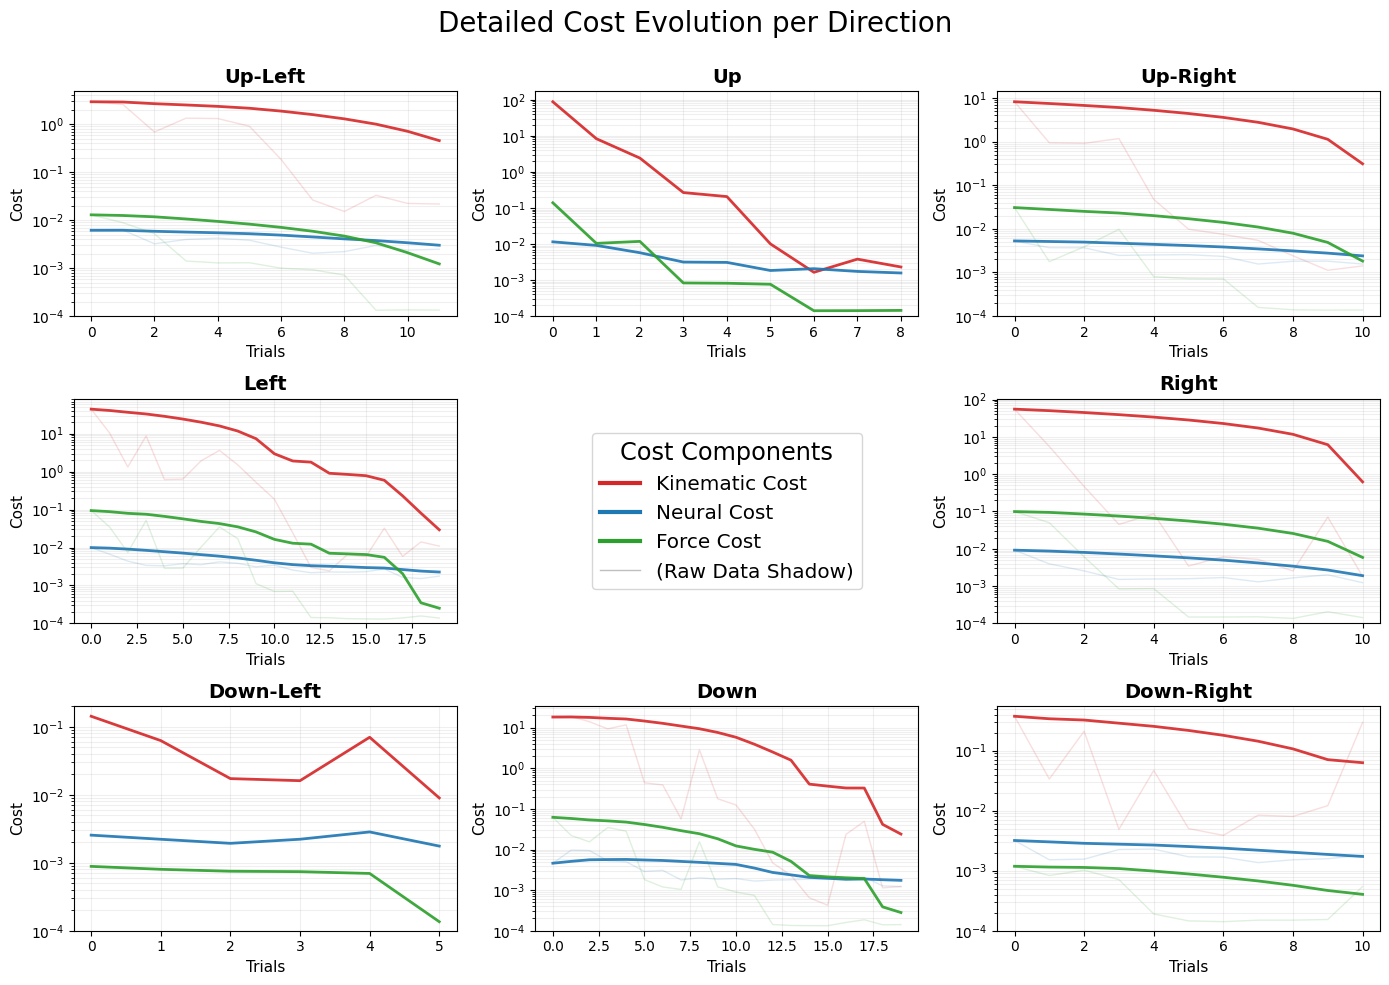

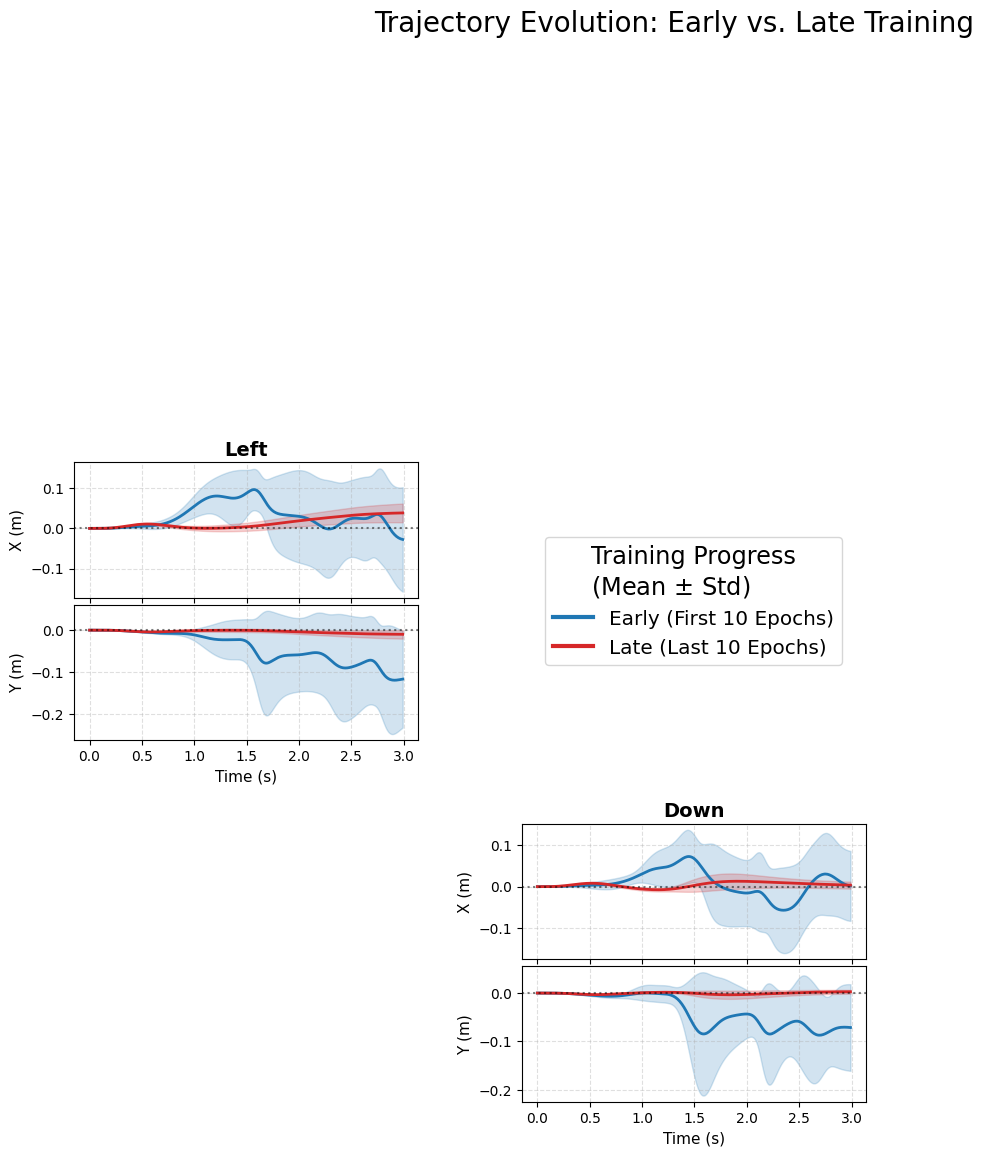

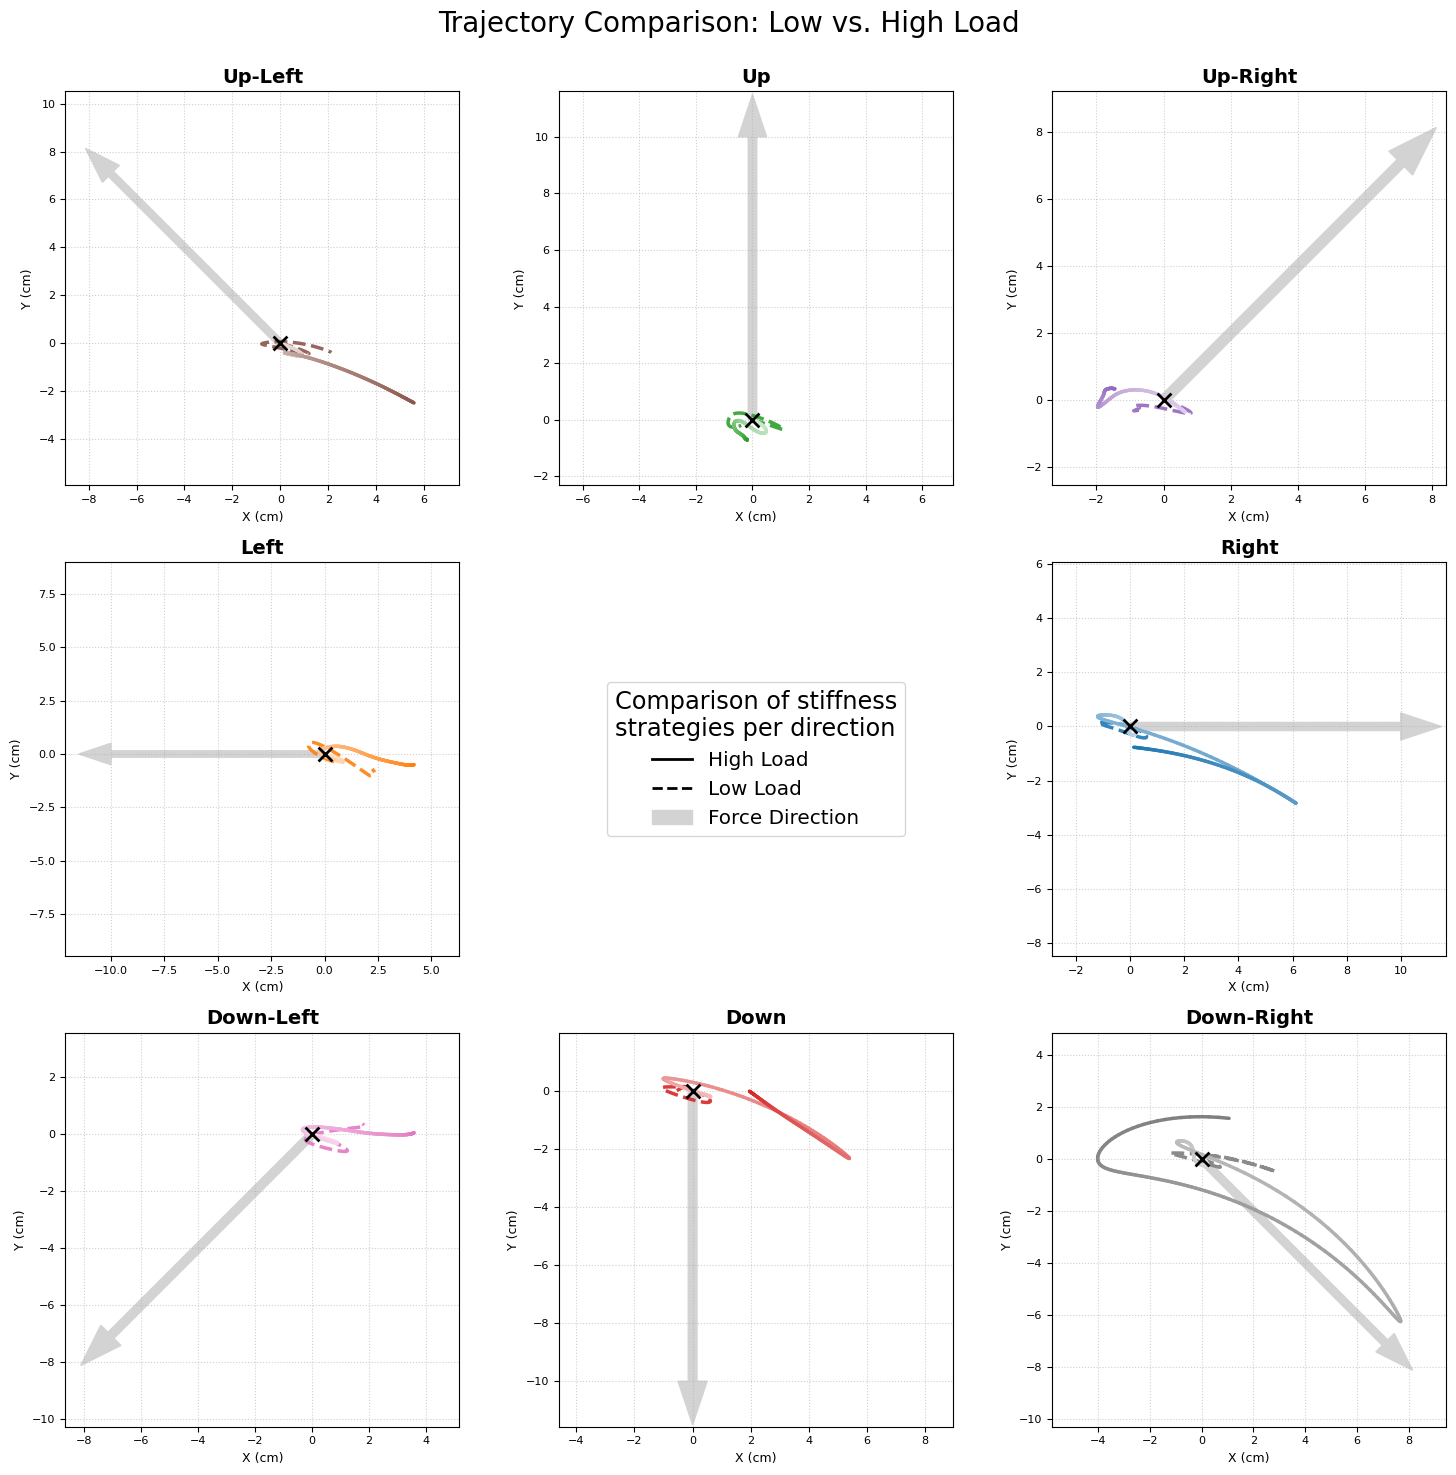

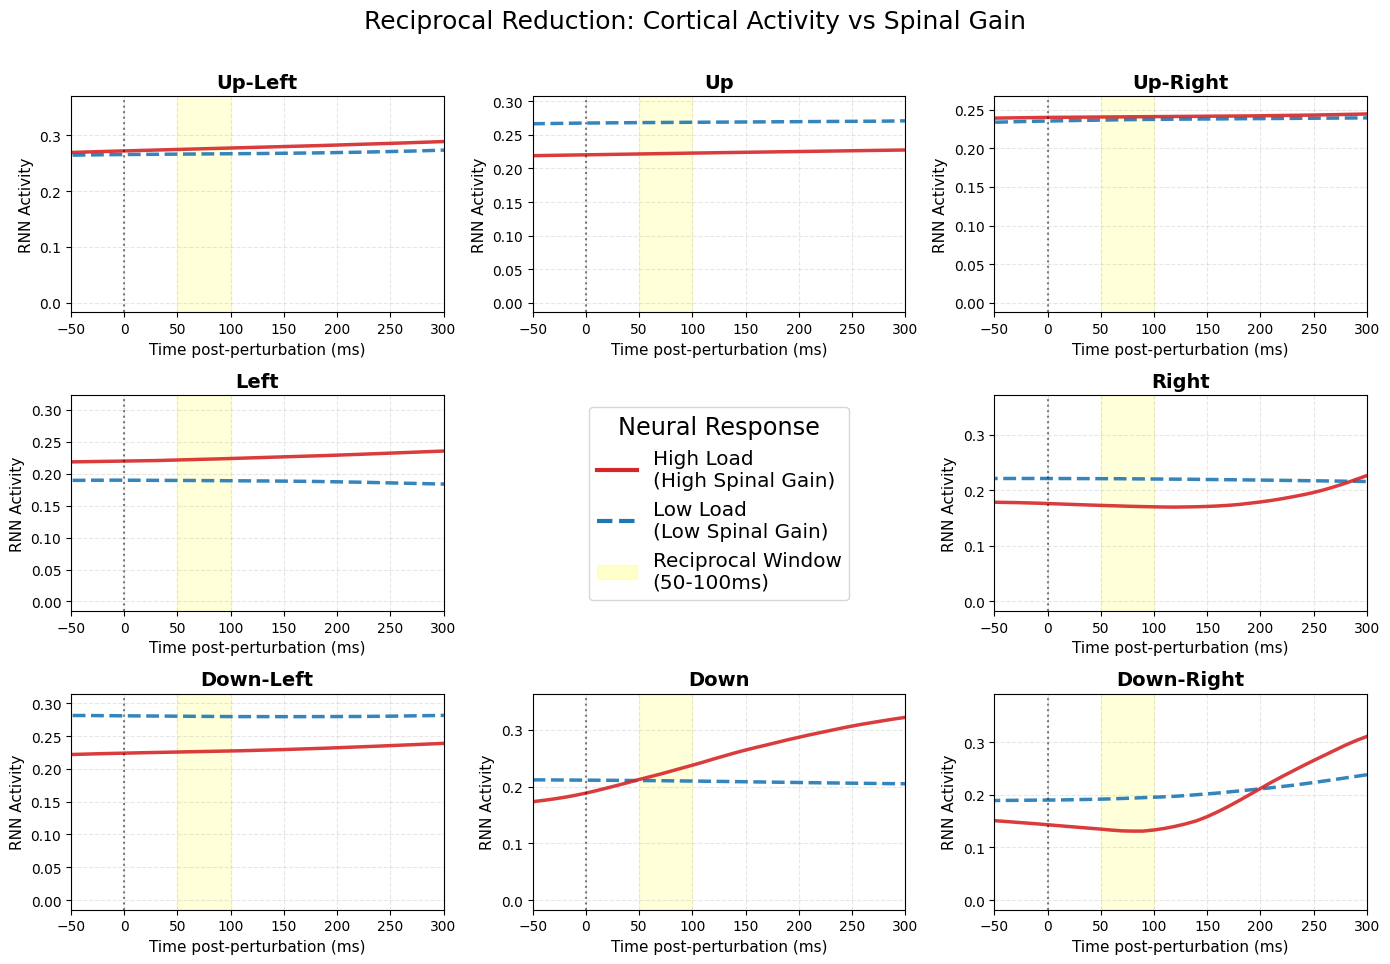

In [92]:
# Initialization
set_seed(42)
num_epochs = 100
env = MyoElbowPose2D6MFixed()
controller = NeuralLimbController(n_inputs=n_inputs, n_outputs=n_muscles)

optimizer = torch.optim.Adam(controller.parameters(), lr=1e-4, weight_decay=1e-5)
torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=1.0)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

if not isinstance(M_m, torch.Tensor):
    M_m_tensor = torch.tensor(M_m, dtype=torch.float32)
else:
    M_m_tensor = M_m.clone().detach().float()

# Storage
epoch_metadata = []
epoch_qpos_over_time = []
epoch_neural_activity = [] 
epoch_costs_over_time = []
target_results = {i: {"pose_errors": [], "rewards": [], "costs": {key: [] for key in ["neural", "force", "kinematic", "total"]}} for i in range(len(perturbation_directions))}


# --- TRAINING LOOP ---
for epoch in range(num_epochs):
    # Detach hidden states
    controller.y_s = controller.y_s.detach()
    controller.y_m = controller.y_m.detach()
    controller.y_act = controller.y_act.detach()

    # 0. Update Costs for this Epoch
    alpha, beta, gamma = get_cost_weights(epoch, num_epochs)

    # 1. Setup Targets
    base_qs, base_qe = np.radians(35), np.radians(90)
    base_x = l1 * np.cos(base_qs) + l2 * np.cos(base_qs + base_qe)
    base_y = l1 * np.sin(base_qs) + l2 * np.sin(base_qs + base_qe)
    offset_x, offset_y = base_x, base_y

    target_qpos = (base_qs, base_qe)
    target_qpos_tensor = torch.tensor([base_qs, base_qe], dtype=torch.float32)

    # 2. Epoch Params
    background_load, load_condition, G_s, perturbation_idx, direction_name = initialize_epoch_params(
        perturbation_directions, background_load_low, background_load_high, G_s_low, G_s_high
    )

    # 3. Reset Env
    obs_numpy = reset_environment_and_controller(env, controller, target_qpos, offset_x, offset_y)
    
    # Force Perfect Start
    env.set_joint_angles([base_qs, 0.0, base_qe, 0.0])
    obs_numpy = env._get_obs()

    # Log metadata
    epoch_metadata.append({"load": load_condition, "direction": direction_name})
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}")

    # 4. Buffers & Init
    activation_buffer = [torch.zeros(n_muscles) for _ in range(activation_delay_steps)]
    delayed_activations = activation_buffer[0]
    previous_act = None
    loss_neural_accum, loss_force_accum, loss_kinematic_accum = 0, 0, 0
    pose_errors, rewards, qpos_over_time = [], [], []
    epoch_costs = {key: [] for key in ["neural", "force", "kinematic", "total"]}
    trial_neural_history = []

    # Init Muscle Lengths
    theta_s_ref, theta_e_ref = obs_numpy[0], obs_numpy[2]
    initial_lengths = compute_muscle_lengths(theta_s_ref, theta_e_ref, theta_s_ref, theta_e_ref, M_m)
    L_m_initial = initial_lengths.clone().detach() 
    
    delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = [torch.zeros(n_muscles) for _ in range(4)]
    
    # CRITICAL: Initialize Tensors that will carry the gradient
    current_qpos = torch.tensor([obs_numpy[0], obs_numpy[2]], dtype=torch.float32)
    current_qvel = torch.tensor([obs_numpy[1], obs_numpy[3]], dtype=torch.float32)
    
    initial_x_m = torch.zeros((n_muscles, 4), dtype=torch.float32)
    initial_aff = (G_aff @ initial_x_m.T).flatten()
    
    # Initialize buffers with Tensors
    cortical_buffer, spinal_buffer = initialize_buffers(
        feedback_delay_steps, reflex_delay, current_qpos, current_qvel, initial_aff
    )

    # --- SIMULATION STEPS ---
    for step in range(T_step):
        # A. Targets & Forces
        desired_force = compute_desired_force(step, Tb_step, Tp_step, Tsp_step, background_load, perturbation_load, perturbation_directions, direction_name)

        # B. Physics Setup
        theta_s, theta_e = current_qpos[0], current_qpos[1]
        
        # 1. Use the current angles for the Jacobian
        J = compute_jacobian(theta_s.detach().item(), theta_e.detach().item(), l1, l2)
        
        # 2. Apply Torque
        tau = -(J.T @ desired_force) 
        tau_tensor = torch.tensor(tau, dtype=torch.float32)
        env.set_external_torque(tau)
        
        # 3. Tare Sensors at Perturbation Onset
        if step == Tp_step:
            theta_s_ref, theta_e_ref = current_qpos[0].item(), current_qpos[1].item()
            ref_lengths = compute_muscle_lengths(
                theta_s_ref, theta_e_ref, theta_s_ref, theta_e_ref, M_m_tensor
            )
            L_m_initial = ref_lengths.clone().detach()

        # C. Update Muscle Kinematics
        L_m, delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m, dLm_dt = update_muscle_kinematics(
            qpos=current_qpos, 
            qvel=current_qvel,
            theta_ref=torch.tensor([theta_s_ref, theta_e_ref]), 
            L_m_init=L_m_initial,                               
            M_m=M_m_tensor, 
            dt=dt,
            vel_Lm_prev=velocity_L_m,          
            acc_Lm_prev=acceleration_L_m       
        )
        
        x_m = torch.stack([delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m], dim=1)
        current_aff = (G_aff @ x_m.T).flatten()

        # D. Muscle Dynamics
        FL_active, FL_passive = ForceLength.compute(L_m)
        FV = ForceVelocity.compute(dLm_dt.squeeze()).detach() 
        F_m = (delayed_activations * FL_active * FV) + FL_passive

        # E. Control Step
        delayed_qpos, delayed_qvel = cortical_buffer[0]
        delayed_aff = spinal_buffer[0]
        
        u_fb_cortical, u_spinal = compute_feedback_signals(
            None, delayed_qpos, delayed_qvel, delayed_aff, 
            target_qpos_tensor, G_p, G_d, G_f, F_m
        )

        delayed_aff = spinal_buffer[0] 
        u_spinal_reflex = (G_s * delayed_aff).detach()

        muscle_activations = controller.forward_step(
            u_fb_cortical, u_spinal_reflex, controller.y_s, controller.y_m, controller.y_act
        )
        trial_neural_history.append(controller.y_m.abs().mean().item())

        update_buffers(cortical_buffer, spinal_buffer, current_qpos, current_qvel, current_aff)
        delayed_activations = activation_buffer.pop(0)
        activation_buffer.append(muscle_activations)
            
        # F. Differentiable Physics Step
        next_qpos, next_qvel = differentiable_physics_step(current_qpos, current_qvel, F_m, tau_tensor, M_m_tensor)
        
        # G. Loss Accumulation
        loss_neural_accum, loss_force_accum, loss_kinematic_accum = accumulate_costs(
            controller, F_m, next_qpos, next_qvel, target_qpos_tensor, 
            loss_neural_accum, loss_force_accum, loss_kinematic_accum, 
            Tsb_step, Tp_step, Tsp_step, step
        )
        
        # Logging (Visuals only)
        obs_display = np.array([next_qpos[0].item(), next_qvel[0].item(), next_qpos[1].item(), next_qvel[1].item()])
        pose_error, (x, y) = compute_pose_error(obs_display, (base_qs, base_qe), l1, l2, offset_x, offset_y)
        pose_errors.append(pose_error)
        qpos_over_time.append((x, y))

        current_qpos = next_qpos
        current_qvel = next_qvel

    # --- END EPOCH ---
    epoch_neural_activity.append(trial_neural_history)

    # Optimization
    total_trial_loss = normalize_and_compute_total_loss(
        loss_neural_accum, loss_force_accum, loss_kinematic_accum, alpha, beta, gamma, T_step
    )
    
    optimizer.zero_grad()
    total_trial_loss.backward()
    
    torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=1.0)
    optimizer.step()

    # Logging
    c_neural = alpha * (loss_neural_accum / T_step).item()
    c_force = beta * (loss_force_accum / T_step).item()
    c_kinematic = gamma * (loss_kinematic_accum / T_step).item()
    
    target_results[perturbation_idx]["costs"]["neural"].append(c_neural)
    target_results[perturbation_idx]["costs"]["force"].append(c_force)
    target_results[perturbation_idx]["costs"]["kinematic"].append(c_kinematic)
    target_results[perturbation_idx]["costs"]["total"].append(c_neural + c_force + c_kinematic)
    target_results[perturbation_idx]["pose_errors"].append(sum(pose_errors) / len(pose_errors))
    target_results[perturbation_idx]["rewards"].append(sum(rewards))
    
    epoch_qpos_over_time.append(qpos_over_time) 
    epoch_costs_over_time.append(epoch_costs) 
    scheduler.step()

# --- ANALYSIS PLOTS ---
plot_detailed_cost_history(target_results)
plot_trajectory_evolution_grid_xy(epoch_qpos_over_time, epoch_metadata)
plot_detailed_trajectory_comparison(epoch_metadata, epoch_qpos_over_time, perturbation_directions)
plot_neural_activity_comparison(epoch_metadata, epoch_neural_activity, Tp_step)

Epoch 100/3000
Epoch 200/3000
Epoch 300/3000
Epoch 400/3000
Epoch 500/3000
Epoch 600/3000
Epoch 700/3000
Epoch 800/3000
Epoch 900/3000
Epoch 1000/3000
Epoch 1100/3000
Epoch 1200/3000
Epoch 1300/3000
Epoch 1400/3000
Epoch 1500/3000
Epoch 1600/3000
Epoch 1700/3000
Epoch 1800/3000
Epoch 1900/3000
Epoch 2000/3000
Epoch 2100/3000
Epoch 2200/3000
Epoch 2300/3000
Epoch 2400/3000
Epoch 2500/3000
Epoch 2600/3000
Epoch 2700/3000
Epoch 2800/3000
Epoch 2900/3000
Epoch 3000/3000


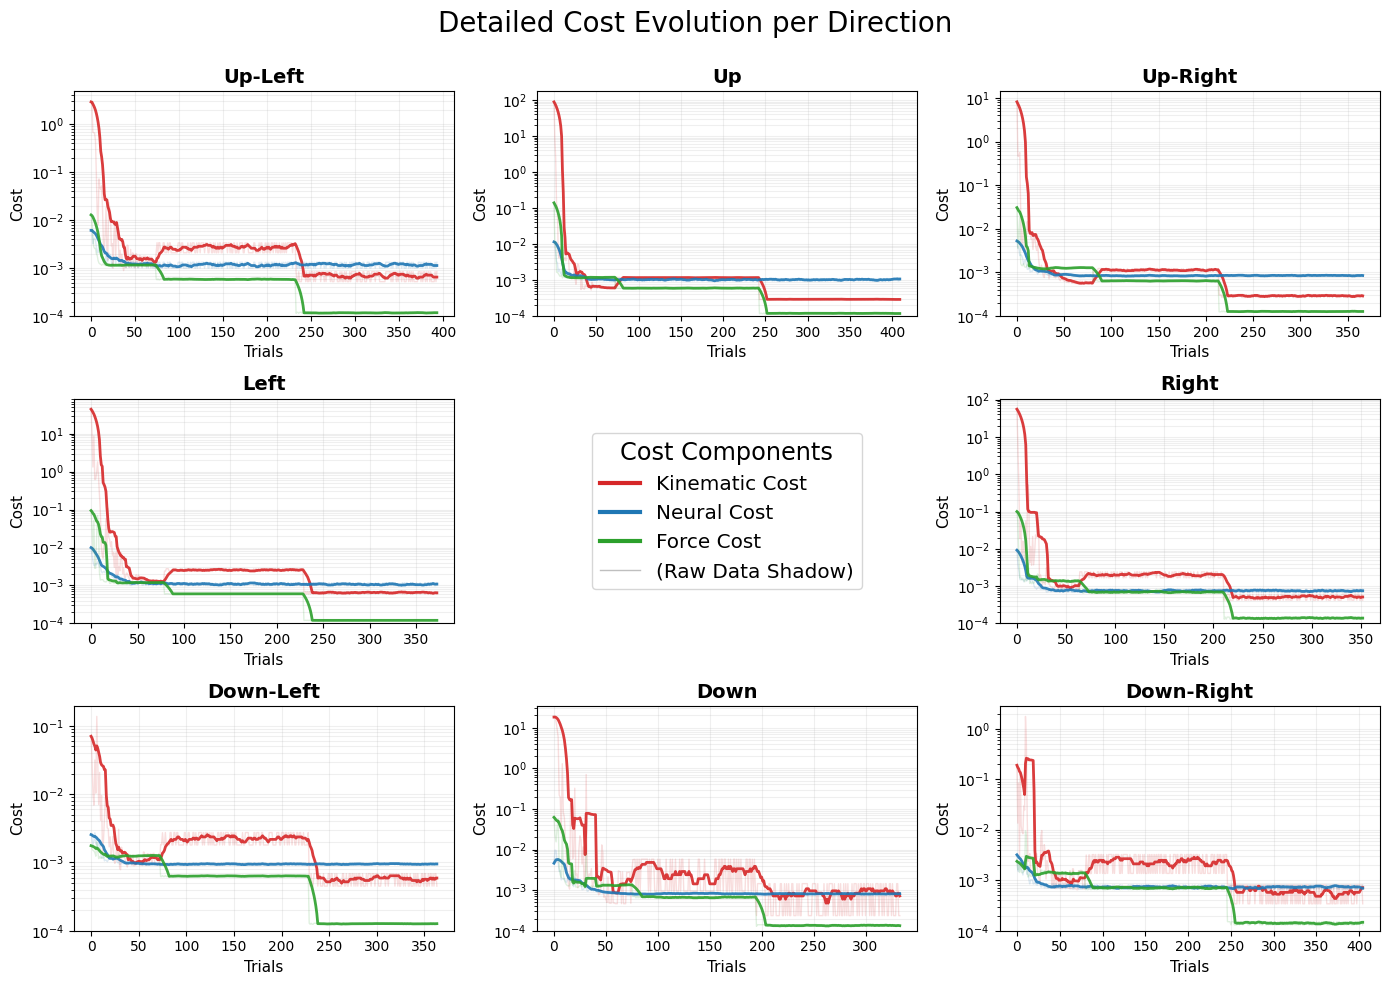

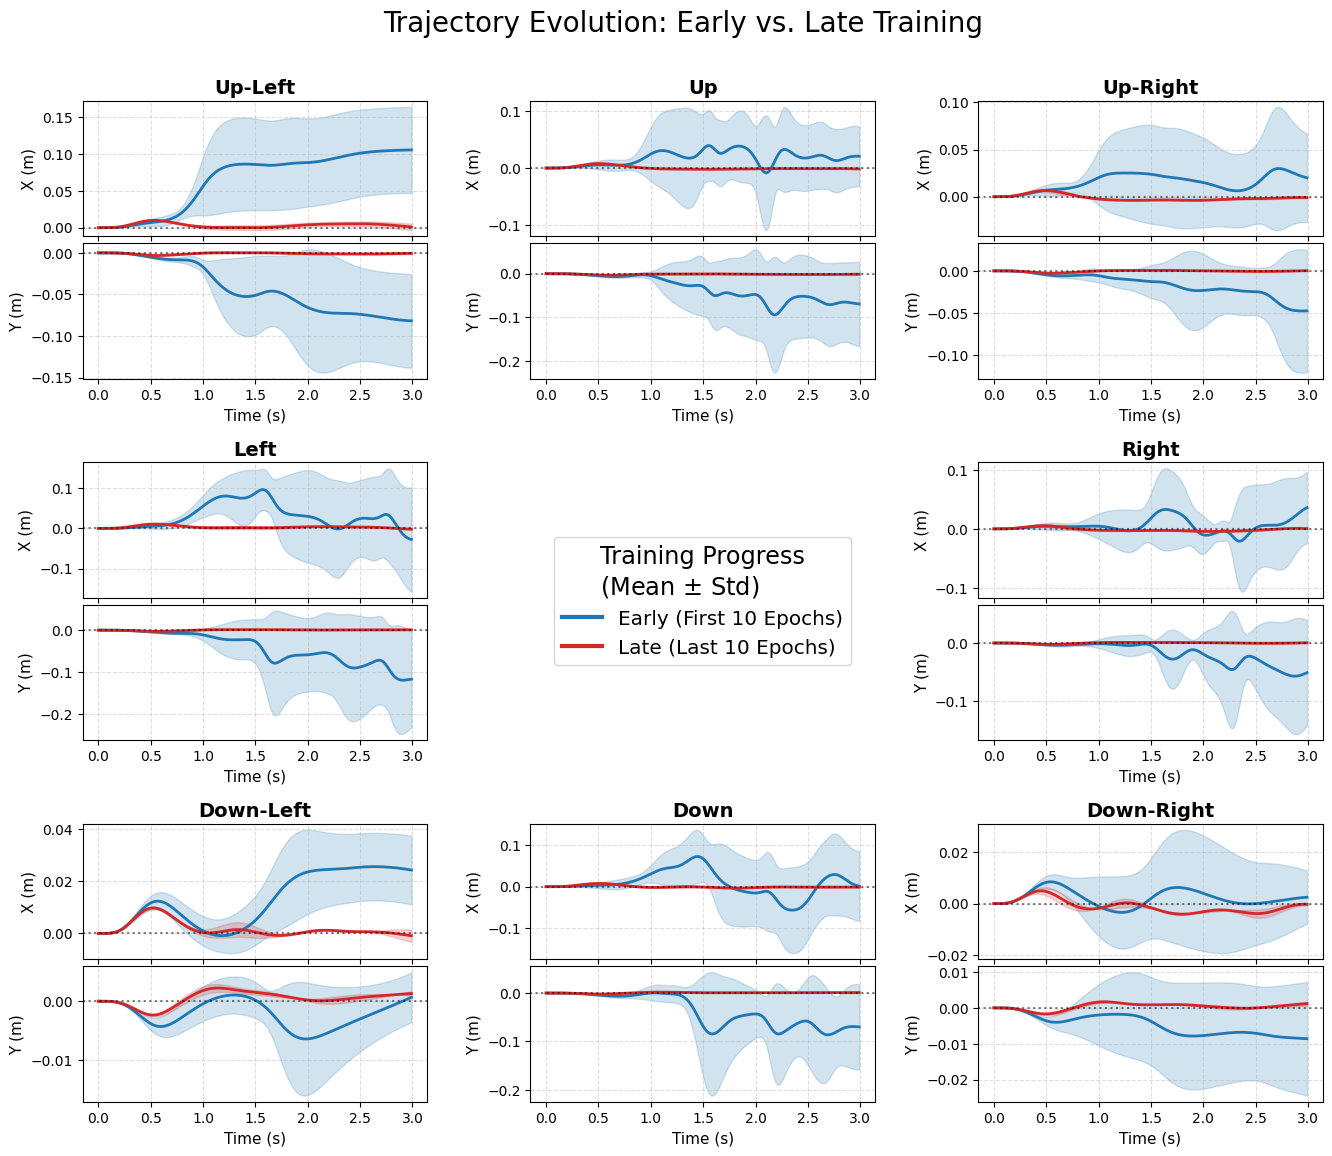

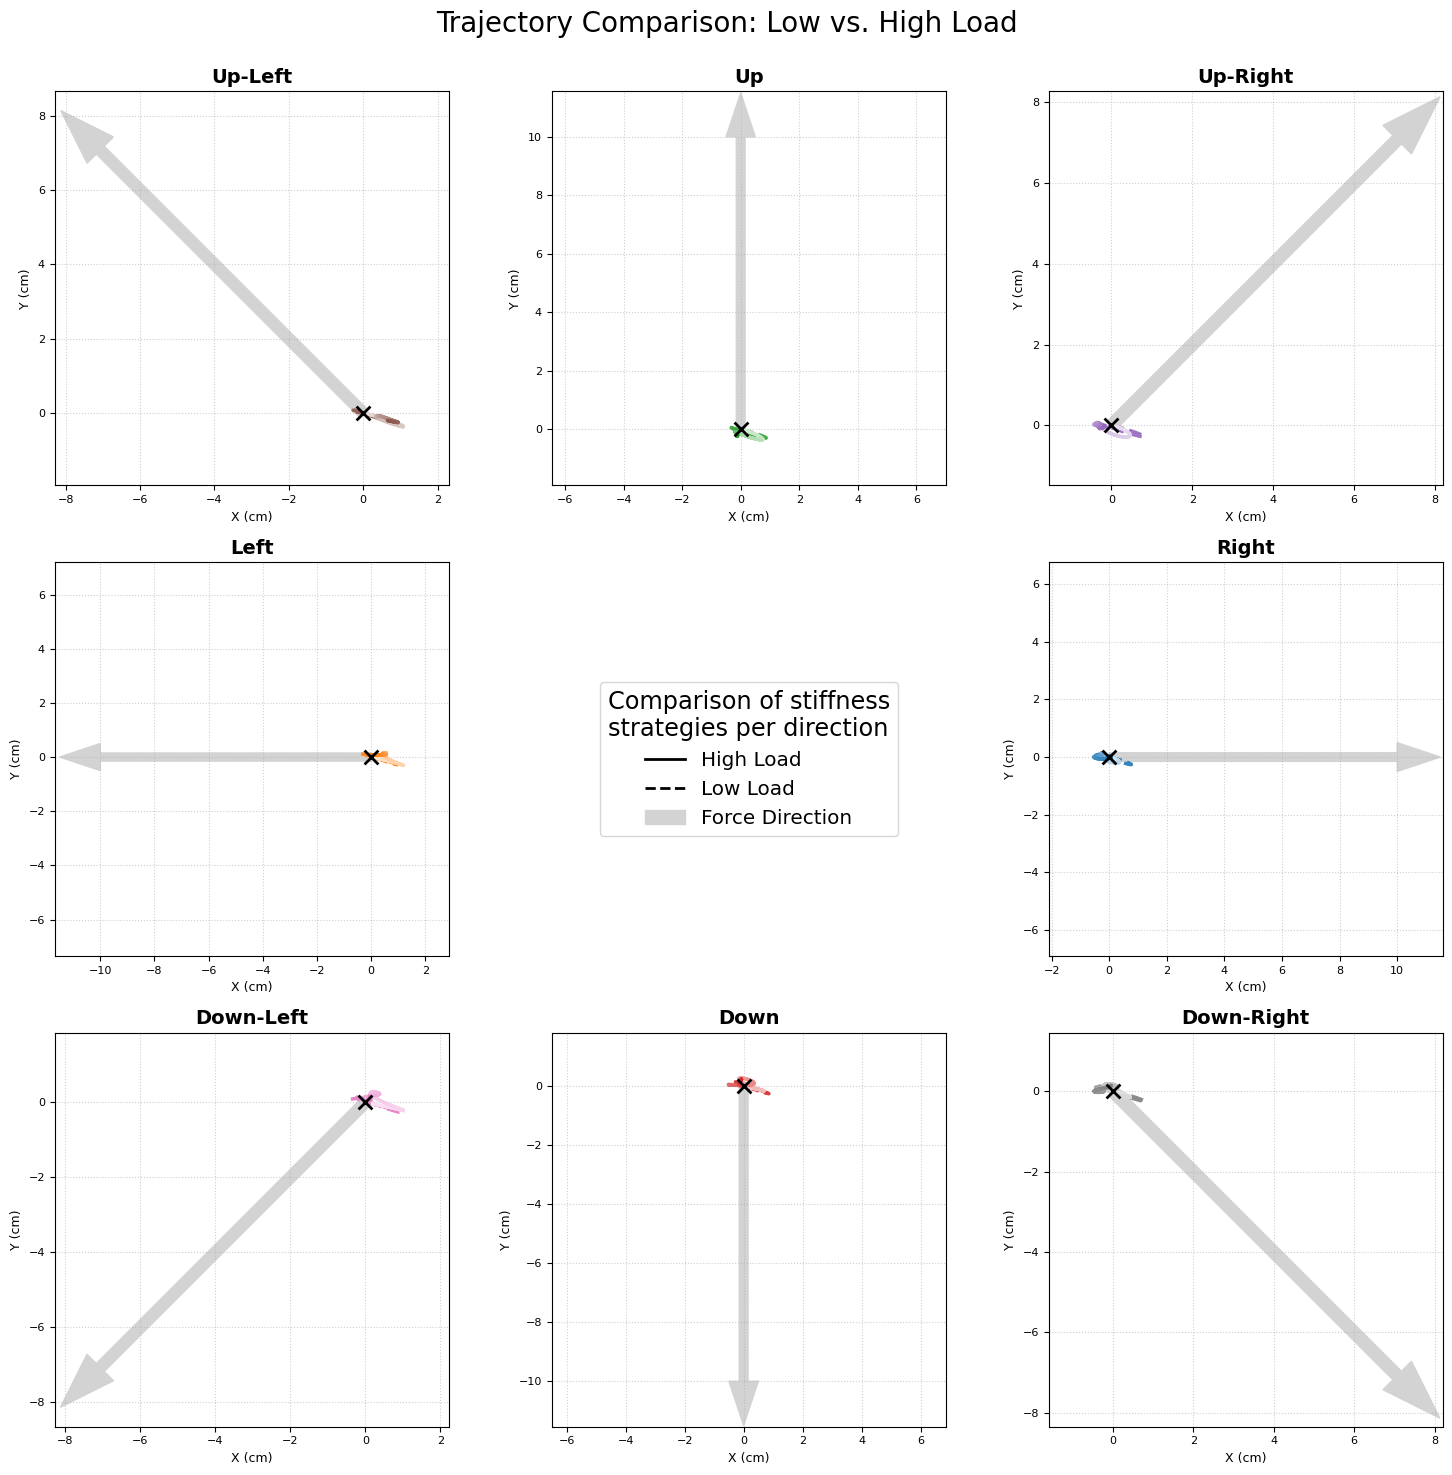

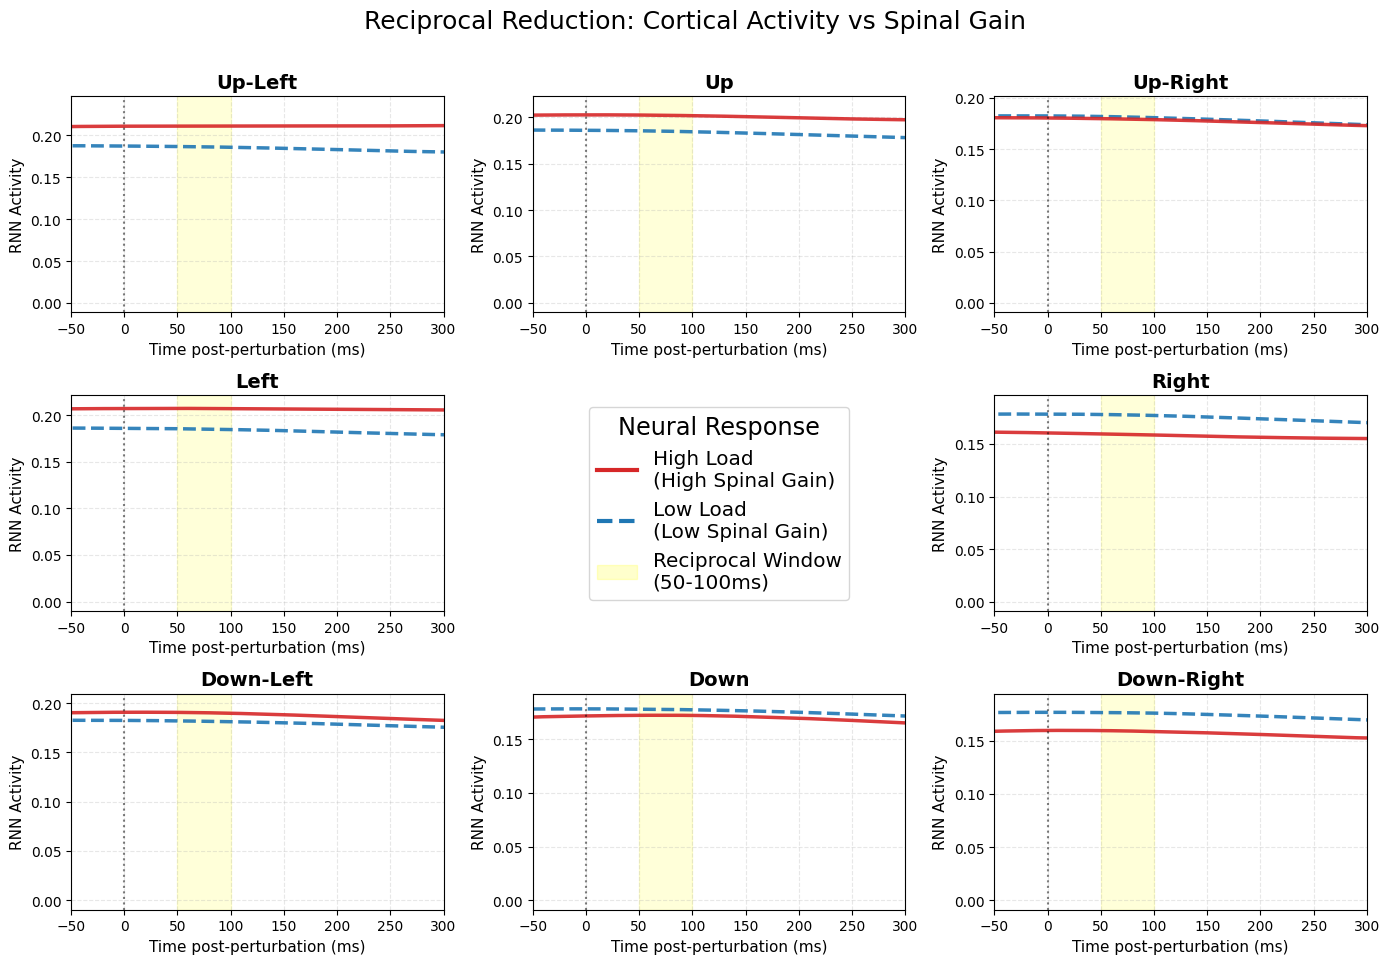

In [93]:
# Initialization
set_seed(42)
num_epochs = 3000
env = MyoElbowPose2D6MFixed()
controller = NeuralLimbController(n_inputs=n_inputs, n_outputs=n_muscles)

optimizer = torch.optim.Adam(controller.parameters(), lr=1e-4, weight_decay=1e-5)
torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=1.0)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

if not isinstance(M_m, torch.Tensor):
    M_m_tensor = torch.tensor(M_m, dtype=torch.float32)
else:
    M_m_tensor = M_m.clone().detach().float()

# Storage
epoch_metadata = []
epoch_qpos_over_time = []
epoch_neural_activity = [] 
epoch_costs_over_time = []
target_results = {i: {"pose_errors": [], "rewards": [], "costs": {key: [] for key in ["neural", "force", "kinematic", "total"]}} for i in range(len(perturbation_directions))}


# --- TRAINING LOOP ---
for epoch in range(num_epochs):
    # Detach hidden states
    controller.y_s = controller.y_s.detach()
    controller.y_m = controller.y_m.detach()
    controller.y_act = controller.y_act.detach()

    # 0. Update Costs for this Epoch
    alpha, beta, gamma = get_cost_weights(epoch, num_epochs)

    # 1. Setup Targets
    base_qs, base_qe = np.radians(35), np.radians(90)
    base_x = l1 * np.cos(base_qs) + l2 * np.cos(base_qs + base_qe)
    base_y = l1 * np.sin(base_qs) + l2 * np.sin(base_qs + base_qe)
    offset_x, offset_y = base_x, base_y

    target_qpos = (base_qs, base_qe)
    target_qpos_tensor = torch.tensor([base_qs, base_qe], dtype=torch.float32)

    # 2. Epoch Params
    background_load, load_condition, G_s, perturbation_idx, direction_name = initialize_epoch_params(
        perturbation_directions, background_load_low, background_load_high, G_s_low, G_s_high
    )

    # 3. Reset Env
    obs_numpy = reset_environment_and_controller(env, controller, target_qpos, offset_x, offset_y)
    
    # Force Perfect Start
    env.set_joint_angles([base_qs, 0.0, base_qe, 0.0])
    obs_numpy = env._get_obs()

    # Log metadata
    epoch_metadata.append({"load": load_condition, "direction": direction_name})
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}")

    # 4. Buffers & Init
    activation_buffer = [torch.zeros(n_muscles) for _ in range(activation_delay_steps)]
    delayed_activations = activation_buffer[0]
    previous_act = None
    loss_neural_accum, loss_force_accum, loss_kinematic_accum = 0, 0, 0
    pose_errors, rewards, qpos_over_time = [], [], []
    epoch_costs = {key: [] for key in ["neural", "force", "kinematic", "total"]}
    trial_neural_history = []

    # Init Muscle Lengths
    theta_s_ref, theta_e_ref = obs_numpy[0], obs_numpy[2]
    initial_lengths = compute_muscle_lengths(theta_s_ref, theta_e_ref, theta_s_ref, theta_e_ref, M_m)
    L_m_initial = initial_lengths.clone().detach() 
    
    delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = [torch.zeros(n_muscles) for _ in range(4)]
    
    # CRITICAL: Initialize Tensors that will carry the gradient
    current_qpos = torch.tensor([obs_numpy[0], obs_numpy[2]], dtype=torch.float32)
    current_qvel = torch.tensor([obs_numpy[1], obs_numpy[3]], dtype=torch.float32)
    
    initial_x_m = torch.zeros((n_muscles, 4), dtype=torch.float32)
    initial_aff = (G_aff @ initial_x_m.T).flatten()
    
    # Initialize buffers with Tensors
    cortical_buffer, spinal_buffer = initialize_buffers(
        feedback_delay_steps, reflex_delay, current_qpos, current_qvel, initial_aff
    )

    # --- SIMULATION STEPS ---
    for step in range(T_step):
        # A. Targets & Forces
        desired_force = compute_desired_force(step, Tb_step, Tp_step, Tsp_step, background_load, perturbation_load, perturbation_directions, direction_name)

        # B. Physics Setup
        theta_s, theta_e = current_qpos[0], current_qpos[1]
        
        # 1. Use the current angles for the Jacobian
        J = compute_jacobian(theta_s.detach().item(), theta_e.detach().item(), l1, l2)
        
        # 2. Apply Torque
        tau = -(J.T @ desired_force) 
        tau_tensor = torch.tensor(tau, dtype=torch.float32)
        env.set_external_torque(tau)
        
        # 3. Tare Sensors at Perturbation Onset
        if step == Tp_step:
            theta_s_ref, theta_e_ref = current_qpos[0].item(), current_qpos[1].item()
            ref_lengths = compute_muscle_lengths(
                theta_s_ref, theta_e_ref, theta_s_ref, theta_e_ref, M_m_tensor
            )
            L_m_initial = ref_lengths.clone().detach()

        # C. Update Muscle Kinematics
        L_m, delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m, dLm_dt = update_muscle_kinematics(
            qpos=current_qpos, 
            qvel=current_qvel,
            theta_ref=torch.tensor([theta_s_ref, theta_e_ref]), 
            L_m_init=L_m_initial,                               
            M_m=M_m_tensor, 
            dt=dt,
            vel_Lm_prev=velocity_L_m,          
            acc_Lm_prev=acceleration_L_m       
        )
        
        x_m = torch.stack([delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m], dim=1)
        current_aff = (G_aff @ x_m.T).flatten()

        # D. Muscle Dynamics
        FL_active, FL_passive = ForceLength.compute(L_m)
        FV = ForceVelocity.compute(dLm_dt.squeeze()).detach() 
        F_m = (delayed_activations * FL_active * FV) + FL_passive

        # E. Control Step
        delayed_qpos, delayed_qvel = cortical_buffer[0]
        delayed_aff = spinal_buffer[0]
        
        u_fb_cortical, u_spinal = compute_feedback_signals(
            None, delayed_qpos, delayed_qvel, delayed_aff, 
            target_qpos_tensor, G_p, G_d, G_f, F_m
        )

        delayed_aff = spinal_buffer[0] 
        u_spinal_reflex = (G_s * delayed_aff).detach()

        muscle_activations = controller.forward_step(
            u_fb_cortical, u_spinal_reflex, controller.y_s, controller.y_m, controller.y_act
        )
        trial_neural_history.append(controller.y_m.abs().mean().item())

        update_buffers(cortical_buffer, spinal_buffer, current_qpos, current_qvel, current_aff)
        delayed_activations = activation_buffer.pop(0)
        activation_buffer.append(muscle_activations)
            
        # F. Differentiable Physics Step
        next_qpos, next_qvel = differentiable_physics_step(current_qpos, current_qvel, F_m, tau_tensor, M_m_tensor)
        
        # G. Loss Accumulation
        loss_neural_accum, loss_force_accum, loss_kinematic_accum = accumulate_costs(
            controller, F_m, next_qpos, next_qvel, target_qpos_tensor, 
            loss_neural_accum, loss_force_accum, loss_kinematic_accum, 
            Tsb_step, Tp_step, Tsp_step, step
        )
        
        # Logging (Visuals only)
        obs_display = np.array([next_qpos[0].item(), next_qvel[0].item(), next_qpos[1].item(), next_qvel[1].item()])
        pose_error, (x, y) = compute_pose_error(obs_display, (base_qs, base_qe), l1, l2, offset_x, offset_y)
        pose_errors.append(pose_error)
        qpos_over_time.append((x, y))

        current_qpos = next_qpos
        current_qvel = next_qvel

    # --- END EPOCH ---
    epoch_neural_activity.append(trial_neural_history)

    # Optimization
    total_trial_loss = normalize_and_compute_total_loss(
        loss_neural_accum, loss_force_accum, loss_kinematic_accum, alpha, beta, gamma, T_step
    )
    
    optimizer.zero_grad()
    total_trial_loss.backward()
    
    torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=1.0)
    optimizer.step()

    # Logging
    c_neural = alpha * (loss_neural_accum / T_step).item()
    c_force = beta * (loss_force_accum / T_step).item()
    c_kinematic = gamma * (loss_kinematic_accum / T_step).item()
    
    target_results[perturbation_idx]["costs"]["neural"].append(c_neural)
    target_results[perturbation_idx]["costs"]["force"].append(c_force)
    target_results[perturbation_idx]["costs"]["kinematic"].append(c_kinematic)
    target_results[perturbation_idx]["costs"]["total"].append(c_neural + c_force + c_kinematic)
    target_results[perturbation_idx]["pose_errors"].append(sum(pose_errors) / len(pose_errors))
    target_results[perturbation_idx]["rewards"].append(sum(rewards))
    
    epoch_qpos_over_time.append(qpos_over_time) 
    epoch_costs_over_time.append(epoch_costs) 
    scheduler.step()

# --- ANALYSIS PLOTS ---
plot_detailed_cost_history(target_results)
plot_trajectory_evolution_grid_xy(epoch_qpos_over_time, epoch_metadata)
plot_detailed_trajectory_comparison(epoch_metadata, epoch_qpos_over_time, perturbation_directions)
plot_neural_activity_comparison(epoch_metadata, epoch_neural_activity, Tp_step)

## 9. Analysis & Summary:

This summary provides a comparative analysis of the neural limb controller's performance at an early training stage (100 epochs) versus a fully converged state (3,000 epochs). The progression demonstrates the clear emergence of robust motor control, sophisticated load management, and biologically plausible neural strategies.

#### **1. Optimization & Cost Evolution: The Curriculum Effect**

The training process utilized a curriculum learning strategy defined by the `get_cost_weights` function. This approach shifted the optimization landscape through three distinct phases: stability, precision, and efficiency.

* **Early Stage (100 Epochs): Rapid Adaptation**

    * **Observation:** The model prioritized the "gross motor task." The kinematic cost (red) dropped by orders of magnitude within the first ~10 epochs.

    * **Interpretation:** The network learned to recruit muscles just enough to prevent the arm from flailing. At this stage, it prioritized crude stabilization over energy efficiency (neural and force costs decreased much more slowly).

* **Late Stage (3,000 Epochs): Fine-Tuning & Efficiency**

    * **Observation:** The full curriculum effect is visible as distinct "step-like" plateaus in the cost history:

        1. **Phase 1 (Stability, Epochs 0-600):** Initial rapid drop as the model learned basic stabilization.
        
        2. **Phase 2 (Precision, Epochs 600-1800):** A temporary increase in the visible kinematic cost value occurred. This was an artifact of doubling the penalty weight (), which successfully forced the optimizer to focus on eliminating microscopic tracking errors.
        3. **Phase 3 (Biological Efficiency, Epochs 1800-3000):** Costs dropped to their lowest levels as penalties were relaxed. The network learned to maintain high performance with minimal neural and muscular effort, mimicking biological energy conservation.

#### **2. Trajectory Evolution: From Oscillation to Robustness**

This comparison highlights the transition from a reactive, untrained controller to a predictive, robust policy.

* **Early Stage (100 Epochs): Reactive Control**

    * **Observation:** Trajectories showed large deviations and high variance (blue shaded regions). The arm was significantly displaced by perturbations and often oscillated before returning to the target.

    * **Interpretation:** The controller was "chasing" the error—reacting to the perturbation after it occurred rather than anticipating the dynamics.

* **Late Stage (3,000 Epochs): Robust Disturbance Rejection**

    * **Observation:** Trajectories became tightly clustered around the origin  with minimal standard deviation (red regions).

    * **Interpretation:** The controller acts as a steep "energy well." It developed a robust policy that generates immediate, precise counter-forces to reject disturbances. The variance is nearly eliminated, validating the successful integration of physics and feedback delays.

#### **3. Load Management: Emergence of Impedance Control**

The most significant behavioral shift occurred in how the model handled varying background loads.

* **Early Stage (100 Epochs): Physical Displacement**

    * **Observation:** High-load trials resulted in noticeably larger displacements than low-load trials.

    * **Interpretation:** The model had not yet learned to compensate for the increased potential energy of the background load. It treated the high load as just "more force to fight" reactively.

* **Late Stage (3,000 Epochs): Perfect Compensation**

    * **Observation:** End-effector trajectories for High and Low loads became nearly identical (cm error). The model appeared almost unbothered by the heavier load.

    * **Interpretation:** This suggests the emergence of Impedance Control Strategies (likely co-contraction). By pre-activating muscles to "stiffen" the arm against the heavy background load, the controller neutralized the perturbation before neural reflexes even needed to engage. It effectively learned the inverse dynamics of the system.

#### **4. Biological Plausibility: Reciprocal Reduction**

A key hypothesis of this study is "reciprocal reduction": When spinal reflex gains are high (High Load), the cortex (M1) should relax, offloading control to the spine.

* **Early Stage (100 Epochs): Inconsistent Strategy**

    * **Observation:** The effect was visible but inconsistent. In many directions, the cortex remained highly active regardless of load.

    * **Interpretation:** The network was still discovering the optimal weight distribution and often relied on cortical drive for all stabilization tasks.

* **Late Stage (3,000 Epochs): Nuanced & Realistic**

    * **Observation:** The "Reciprocal Reduction" effect persisted but remained direction-dependent.

        * **Where it works:** In directions with clear mechanical advantage (e.g., pure flexion/extension), the cortex successfully "trusted" the spinal reflex, reducing its activity.
        
        * **Where it doesn't:** In complex directions (e.g., diagonals involving interaction torques), the simple stretch reflex was insufficient. The cortex remained active to coordinate joint interaction.

    * **Interpretation:** This is a highly realistic result. It mirrors biological reality where reflexes alone cannot resolve complex dynamic conflicts (like Coriolis forces), requiring the cortex to remain involved even when reflex gains are high.

#### **Conclusion**

The progression from 100 to 3,000 epochs validates the training pipeline as a tool for studying biological motor control. The model successfully evolved from a crude stabilizer into a sophisticated, energy-efficient controller. It mastered the complex task of load compensation through impedance modulation and exhibited emerging (though nuanced) strategies for neural resource allocation.